# Import libraries

In [1]:
!pip install -q diffusers

In [2]:
!gdown 194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj

!unzip -q celeba_hq_256.zip

Downloading...
From (original): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj
From (redirected): https://drive.google.com/uc?id=194DqJkUjjtlUCp7Sd2DkXgwu7SuBFsrj&confirm=t&uuid=17158dd1-7fa2-44cb-b8c6-f510ab96371b
To: /content/celeba_hq_256.zip
100% 297M/297M [00:05<00:00, 57.4MB/s]


In [1]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from diffusers import DPMSolverMultistepScheduler, UniPCMultistepScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
IMG_DIR = "./celeba_hq_256"

SEED = 42

TRAIN_RATIO = 0.9
BATCH_SIZE = 512
IMAGE_SIZE = 64

# UNET Config

UNET_BLOCK_OUT_CHANNELS = (128, 128, 256, 256)

UNET_DOWN_BLOCK_TYPES = (
    "DownBlock2D",
    "DownBlock2D",
    "AttnDownBlock2D",
    "DownBlock2D",
)

UNET_UP_BLOCK_TYPES = (
    "UpBlock2D",
    "AttnUpBlock2D",
    "UpBlock2D",
    "UpBlock2D",
)

LAYERS_PER_BLOCK = 2

In [3]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Utils

In [4]:
def denormalize(x):
    # Convert [-1, 1] -> [0, 1]
    return (x + 1) / 2


def show_batch(images, nrow=8, title=None):
    images = denormalize(images.detach().cpu()).clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    img = ToPILImage()(grid)

    plt.figure(figsize=(14, 6))
    if title is not None:
        plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def compose_inpaint(pred_image, masked_image, mask):
    return masked_image * (1 - mask) + pred_image * mask

In [5]:
def masked_mae_loss(pred, target, mask, eps=1e-8):
    """
    Tính MAE trung bình chỉ trên vùng mask.
    pred, target: [B, 3, H, W]
    mask: [B, 1, H, W]
    """
    loss = torch.abs(pred - target) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


def masked_mse_loss(pred, target, mask, eps=1e-8):
    """
    Tính MSE trung bình chỉ trên vùng mask.
    """
    loss = ((pred - target) ** 2) * mask
    return loss.sum() / (mask.sum() * pred.shape[1] + eps)


In [6]:
def build_unet_7ch():
    model = UNet2DModel(
        sample_size=IMAGE_SIZE,
        in_channels=7,
        out_channels=3,
        layers_per_block=LAYERS_PER_BLOCK,
        block_out_channels=UNET_BLOCK_OUT_CHANNELS,
        down_block_types=UNET_DOWN_BLOCK_TYPES,
        up_block_types=UNET_UP_BLOCK_TYPES,
    )
    return model

In [7]:
def load_checkpoint(
    checkpoint_path,
    model_type,
    device,
    image_size=256,
    z_dim=256,
    channels=(64, 128, 256, 256),
):
    """
    model_type:
        "vae"
        "diffusion"
        "flow"
    """

    model_type = model_type.lower()

    if model_type == "diffusion":
        model = build_unet_7ch().to(device)

    else:
        raise ValueError(
            f"Unknown model_type={model_type}. "
            "Use 'vae', 'diffusion', or 'flow'."
        )

    state_dict = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded {model_type} checkpoint from: {checkpoint_path}")

    return model

# Dataset & Dataloader

In [8]:
def bbox2mask(img_shape, bbox, dtype="uint8"):
    """
    bbox = (top, left, height, width)
    mask = 1 ở vùng bị che, 0 ở vùng giữ lại.
    """
    height, width = img_shape[:2]

    mask = np.zeros((height, width, 1), dtype=dtype)
    mask[
        bbox[0]:bbox[0] + bbox[2],
        bbox[1]:bbox[1] + bbox[3],
        :
    ] = 1

    return mask

In [9]:
class InpaintingDataset(Dataset):
    def __init__(self, img_paths, image_size=(256, 256), random_mask=False):
        self.img_paths = img_paths
        self.image_size = image_size
        self.random_mask = random_mask

        self.tfs = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

    def __len__(self):
        return len(self.img_paths)

    def get_mask(self):
        h, w = self.image_size

        if self.random_mask:
            mask_h = random.randint(h // 4, h // 3)
            mask_w = random.randint(w // 4, w // 3)

            top = random.randint(0, h - mask_h)
            left = random.randint(0, w - mask_w)
        else:
            mask_h = h // 3
            mask_w = w // 3

            top = (h - mask_h) // 2
            left = (w - mask_w) // 2

        mask = bbox2mask(
            self.image_size,
            bbox=(top, left, mask_h, mask_w)
        )

        mask = torch.from_numpy(mask).permute(2, 0, 1).float()
        return mask

    def __getitem__(self, index):
        img_path = self.img_paths[index]

        img = Image.open(img_path).convert("RGB")
        gt_image = self.tfs(img)

        mask = self.get_mask()

        # Condition chung cho VAE / Diffusion / Flow Matching:
        # known region giữ ảnh thật, missing region fill bằng -1
        cond_image = gt_image * (1 - mask) + (-1.0) * mask

        return {
            "gt_image": gt_image,
            "cond_image": cond_image,
            "mask": mask,
            "path": img_path,
        }

In [10]:
file_names = sorted(os.listdir(IMG_DIR))
img_paths = [os.path.join(IMG_DIR, f) for f in file_names]

random.shuffle(img_paths)

split_idx = int(len(img_paths) * TRAIN_RATIO)

train_imgpaths = img_paths[:split_idx]
val_imgpaths = img_paths[split_idx:]

print("Train:", len(train_imgpaths))
print("Val:", len(val_imgpaths))

Train: 27000
Val: 3000


In [11]:
train_dataset = InpaintingDataset(
    train_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

val_dataset = InpaintingDataset(
    val_imgpaths,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    random_mask=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    drop_last=False,
)

print("Train loader:", len(train_loader))
print("Val loader:", len(val_loader))

Train loader: 52
Val loader: 6


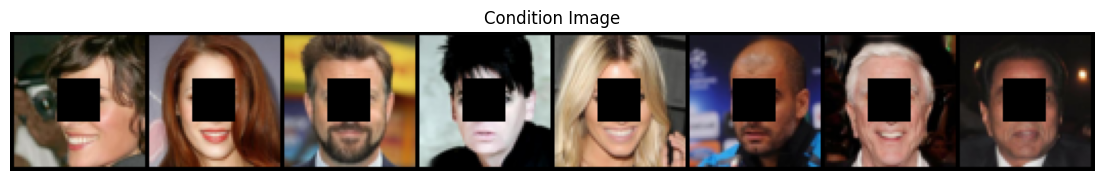

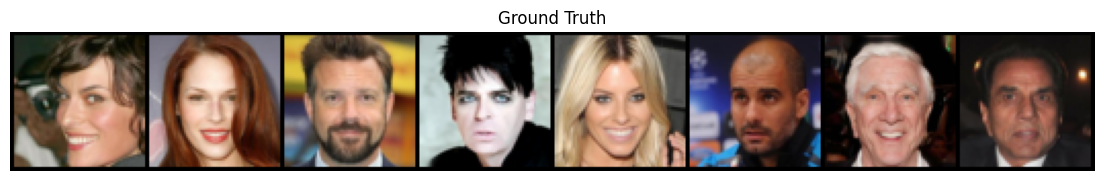

In [12]:
sample = next(iter(train_loader))

gt_image = sample["gt_image"]
cond_image = sample["cond_image"]
mask = sample["mask"]

show_batch(cond_image[:8], nrow=8, title="Condition Image")
show_batch(gt_image[:8], nrow=8, title="Ground Truth")

# Model

## Model definition

In [13]:
diffusion_model = build_unet_7ch().to(device)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="sample",
)

diffusion_optimizer = torch.optim.AdamW(
    diffusion_model.parameters(),
    lr=5e-5,
    weight_decay=1e-4,
)

total_params = sum(
    p.numel() for p in diffusion_model.parameters()
    if p.requires_grad
)
print(f"Diffusion total parameters: {total_params:,}")

os.makedirs("Diffusion", exist_ok=True)

Diffusion total parameters: 28,486,915


## Trainer

In [14]:
def predict_x0_from_epsilon(
    scheduler,
    x_t,
    timesteps,
    pred_noise,
    clamp=False,
):
    """
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * epsilon

    => x0_hat = (x_t - sqrt(1 - alpha_bar_t) * epsilon_hat)
                / sqrt(alpha_bar_t)
    """

    alpha_prod_t = scheduler.alphas_cumprod[timesteps].to(x_t.device)
    alpha_prod_t = alpha_prod_t.view(-1, 1, 1, 1)

    sqrt_alpha_prod_t = alpha_prod_t.sqrt()
    sqrt_one_minus_alpha_prod_t = (1.0 - alpha_prod_t).sqrt()

    pred_x0 = (
        x_t - sqrt_one_minus_alpha_prod_t * pred_noise
    ) / sqrt_alpha_prod_t

    if clamp:
        pred_x0 = pred_x0.clamp(-1, 1)

    return pred_x0

In [15]:
def diffusion_train_step(
    model,
    data,
    optimizer,
    noise_scheduler,
    device,
    mse_weight=0.1,
):
    model.train()

    gt_image = data["gt_image"].to(device)
    cond_image = data["cond_image"].to(device)
    mask = data["mask"].to(device).float()

    batch_size = gt_image.size(0)

    noise = torch.randn_like(gt_image)

    timesteps = torch.randint(
        low=0,
        high=noise_scheduler.config.num_train_timesteps,
        size=(batch_size,),
        device=device,
    ).long()

    # Forward diffusion trên ảnh thật
    x_t = noise_scheduler.add_noise(
        original_samples=gt_image,
        noise=noise,
        timesteps=timesteps,
    )

    # Inpainting state:
    # known region giữ sạch, missing region bị noise theo timestep
    x_t_inpaint = gt_image * (1 - mask) + x_t * mask

    model_input = torch.cat(
        [x_t_inpaint, cond_image, mask],
        dim=1
    )

    # prediction_type="sample": model output là pred_x0
    pred_x0 = model(
        model_input,
        timesteps
    ).sample

    # Chỉ học vùng mask
    loss_mae = masked_mae_loss(
        pred_x0,
        gt_image,
        mask
    )

    loss_mse = masked_mse_loss(
        pred_x0,
        gt_image,
        mask
    )

    loss = loss_mae + mse_weight * loss_mse

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "loss_mae": loss_mae.item(),
        "loss_mse": loss_mse.item(),
    }

## Evaluate

In [16]:
@torch.no_grad()
def evaluate_diffusion(
    model,
    val_loader,
    noise_scheduler,
    device,
    mse_weight=0.1,
):
    model.eval()

    total_loss = 0.0
    total_mae = 0.0
    total_mse = 0.0

    for data in val_loader:
        gt_image = data["gt_image"].to(device)
        cond_image = data["cond_image"].to(device)
        mask = data["mask"].to(device).float()

        batch_size = gt_image.size(0)

        noise = torch.randn_like(gt_image)

        timesteps = torch.randint(
            low=0,
            high=noise_scheduler.config.num_train_timesteps,
            size=(batch_size,),
            device=device,
        ).long()

        x_t = noise_scheduler.add_noise(
            original_samples=gt_image,
            noise=noise,
            timesteps=timesteps,
        )

        x_t_inpaint = gt_image * (1 - mask) + x_t * mask

        model_input = torch.cat(
            [x_t_inpaint, cond_image, mask],
            dim=1
        )

        pred_x0 = model(
            model_input,
            timesteps
        ).sample

        loss_mae = masked_mae_loss(
            pred_x0,
            gt_image,
            mask
        )

        loss_mse = masked_mse_loss(
            pred_x0,
            gt_image,
            mask
        )

        loss = loss_mae + mse_weight * loss_mse

        total_loss += loss.item()
        total_mae += loss_mae.item()
        total_mse += loss_mse.item()

    n = len(val_loader)

    return {
        "val_loss": total_loss / n,
        "val_mae": total_mae / n,
        "val_mse": total_mse / n,
    }

## Training

In [17]:
diffusion_epochs = 100
best_val_loss = float("inf")

mse_weight = 0.1

patience = 5
epochs_no_improve = 0

os.makedirs("Diffusion", exist_ok=True)

for epoch in range(diffusion_epochs):
    diffusion_model.train()

    total_loss = 0.0
    total_mae = 0.0
    total_mse = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"[Diffusion] Epoch {epoch + 1}/{diffusion_epochs}"
    )

    for data in pbar:
        metrics = diffusion_train_step(
            model=diffusion_model,
            data=data,
            optimizer=diffusion_optimizer,
            noise_scheduler=noise_scheduler,
            device=device,
            mse_weight=mse_weight,
        )

        total_loss += metrics["loss"]
        total_mae += metrics["loss_mae"]
        total_mse += metrics["loss_mse"]

        pbar.set_postfix({
            "loss": metrics["loss"],
            "mae": metrics["loss_mae"],
            "mse": metrics["loss_mse"],
        })

    train_loss = total_loss / len(train_loader)
    train_mae = total_mae / len(train_loader)
    train_mse = total_mse / len(train_loader)

    val_metrics = evaluate_diffusion(
        model=diffusion_model,
        val_loader=val_loader,
        noise_scheduler=noise_scheduler,
        device=device,
        mse_weight=mse_weight,
    )

    print(
        f"[Diffusion] Epoch {epoch + 1}: "
        f"train_loss={train_loss:.5f}, "
        f"train_mae={train_mae:.5f}, "
        f"train_mse={train_mse:.5f}, "
        f"val_loss={val_metrics['val_loss']:.5f}, "
        f"val_mae={val_metrics['val_mae']:.5f}, "
        f"val_mse={val_metrics['val_mse']:.5f}"
    )

    if (epoch + 1) % 10 == 0:
        torch.save(
            diffusion_model.state_dict(),
            f"Diffusion/diffusion_epoch_{epoch + 1}.pth"
        )

    if val_metrics["val_loss"] < best_val_loss:
        best_val_loss = val_metrics["val_loss"]
        epochs_no_improve = 0

        torch.save(
            diffusion_model.state_dict(),
            "Diffusion/diffusion_best.pth"
        )

        print(
            f"Saved best Diffusion checkpoint at epoch {epoch + 1} "
            f"with val_loss={best_val_loss:.5f}"
        )

    else:
        epochs_no_improve += 1

        print(
            f"No improvement for {epochs_no_improve}/{patience} epochs. "
            f"Best val_loss={best_val_loss:.5f}"
        )

        if epochs_no_improve >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best val_loss={best_val_loss:.5f}"
            )
            break

[Diffusion] Epoch 1/100: 100%|██████████| 52/52 [01:00<00:00,  1.16s/it, loss=0.169, mae=0.164, mse=0.0488]


[Diffusion] Epoch 1: train_loss=0.23023, train_mae=0.22007, train_mse=0.10162, val_loss=0.16305, val_mae=0.15850, val_mse=0.04548
Saved best Diffusion checkpoint at epoch 1 with val_loss=0.16305


[Diffusion] Epoch 2/100: 100%|██████████| 52/52 [00:59<00:00,  1.15s/it, loss=0.135, mae=0.132, mse=0.0319]


[Diffusion] Epoch 2: train_loss=0.14720, train_mae=0.14341, train_mse=0.03794, val_loss=0.13533, val_mae=0.13209, val_mse=0.03233
Saved best Diffusion checkpoint at epoch 2 with val_loss=0.13533


[Diffusion] Epoch 3/100: 100%|██████████| 52/52 [00:59<00:00,  1.15s/it, loss=0.125, mae=0.122, mse=0.0275]


...

[Diffusion] Epoch 29: train_loss=0.06417, train_mae=0.06333, train_mse=0.00842, val_loss=0.07914, val_mae=0.07779, val_mse=0.01350
No improvement for 3/5 epochs. Best val_loss=0.07912


[Diffusion] Epoch 30/100: 100%|██████████| 52/52 [00:59<00:00,  1.15s/it, loss=0.0605, mae=0.0598, mse=0.00746]


[Diffusion] Epoch 30: train_loss=0.06341, train_mae=0.06259, train_mse=0.00820, val_loss=0.08032, val_mae=0.07893, val_mse=0.01392
No improvement for 4/5 epochs. Best val_loss=0.07912


[Diffusion] Epoch 31/100: 100%|██████████| 52/52 [00:59<00:00,  1.15s/it, loss=0.0644, mae=0.0635, mse=0.00847]


[Diffusion] Epoch 31: train_loss=0.06266, train_mae=0.06186, train_mse=0.00800, val_loss=0.08021, val_mae=0.07884, val_mse=0.01370
No improvement for 5/5 epochs. Best val_loss=0.07912
Early stopping at epoch 31. Best val_loss=0.07912


## Inference

In [18]:
diffusion_model = load_checkpoint(
    checkpoint_path="/content/Diffusion/diffusion_best.pth",
    model_type="diffusion",
    device=device,
)

Loaded diffusion checkpoint from: /content/Diffusion/diffusion_best.pth


### DDIM

In [19]:
@torch.no_grad()
def diffusion_inpaint(
    model,
    cond_image,
    mask,
    num_inference_steps=100,
    device=None,
):
    model.eval()

    if device is None:
        device = cond_image.device

    cond_image = cond_image.to(device)
    mask = mask.to(device).float()

    # cond_image: known region giữ ảnh thật, missing region = -1
    # visible_image: known region giữ ảnh thật, missing region = 0
    visible_image = cond_image * (1 - mask)

    ddim_scheduler = DDIMScheduler(
        num_train_timesteps=1000,
        beta_schedule="squaredcos_cap_v2",
        prediction_type="sample",
    )

    ddim_scheduler.set_timesteps(
        num_inference_steps,
        device=device
    )

    # x_T: known region sạch, missing region là Gaussian noise
    x = torch.randn_like(cond_image)
    x = visible_image + x * mask

    for t in tqdm(ddim_scheduler.timesteps, desc="DDIM Inpainting Sampling"):
        batch_size = x.size(0)

        t_batch = torch.full(
            (batch_size,),
            int(t.item()) if torch.is_tensor(t) else int(t),
            device=device,
            dtype=torch.long,
        )

        # Ép known region sạch trước prediction
        x = visible_image + x * mask

        model_input = torch.cat(
            [x, cond_image, mask],
            dim=1
        )

        # prediction_type="sample": model output là pred_x0
        pred_x0 = model(
            model_input,
            t_batch
        ).sample

        x = ddim_scheduler.step(
            model_output=pred_x0,
            timestep=t,
            sample=x,
        ).prev_sample

        # Ép known region sạch sau update
        x = visible_image + x * mask

    return x.clamp(-1, 1)

In [35]:
diffusion_model.eval()

sample = next(iter(val_loader))

gt_image = sample["gt_image"].to(device)
cond_image = sample["cond_image"].to(device)
mask = sample["mask"].to(device).float()

with torch.no_grad():
    diffusion_result = diffusion_inpaint(
        model=diffusion_model,
        cond_image=cond_image,
        mask=mask,
        num_inference_steps=150,
        device=device,
    )

all_gt = gt_image.detach().cpu()
all_cond = cond_image.detach().cpu()
all_result = diffusion_result.detach().cpu()

DDIM Inpainting Sampling: 100%|██████████| 150/150 [00:58<00:00,  2.57it/s]


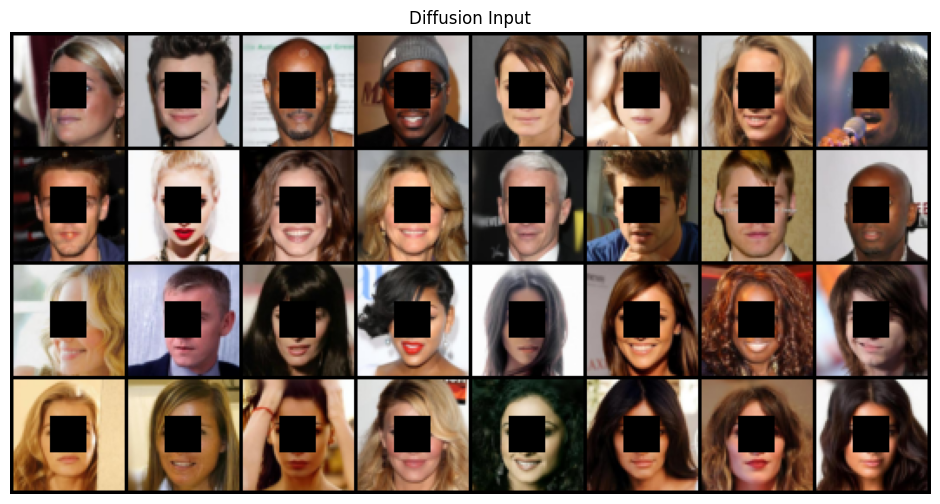

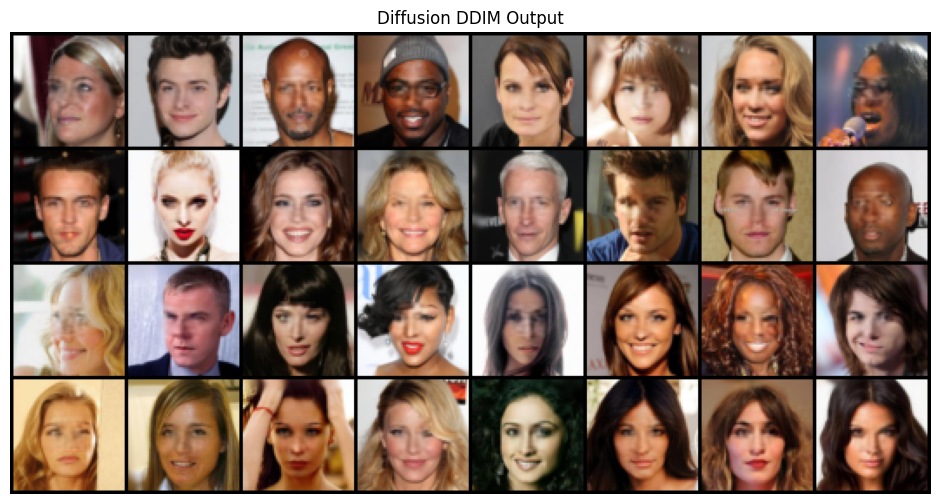

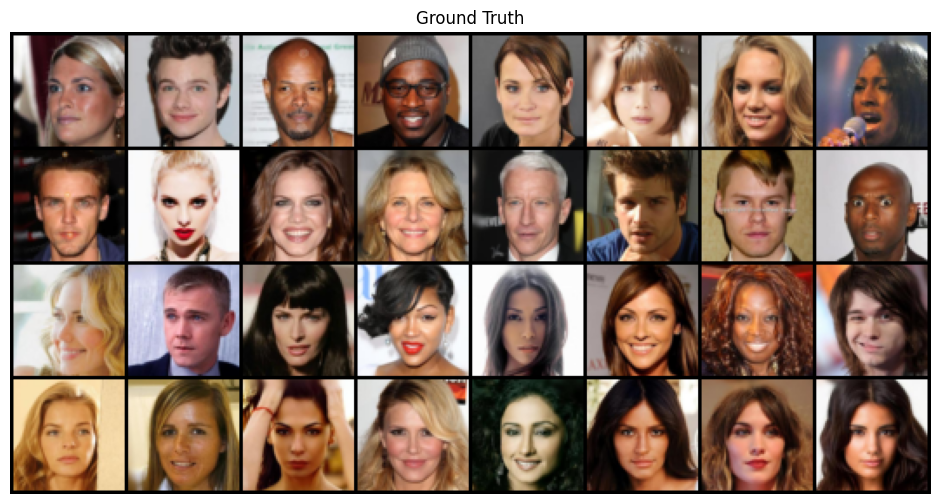

In [36]:
show_batch(all_cond[:32], nrow=8, title="Diffusion Input")
show_batch(all_result[:32], nrow=8, title="Diffusion DDIM Output")
show_batch(all_gt[:32], nrow=8, title="Ground Truth")

### DPM-Solver++

In [22]:
@torch.no_grad()
def diffusion_inpaint_dpm_solver(
    model,
    cond_image,
    mask,
    num_inference_steps=100,
    device=None,
):
    model.eval()

    if device is None:
        device = cond_image.device

    cond_image = cond_image.to(device)
    mask = mask.to(device).float()

    # cond_image: known region giữ ảnh thật, missing region = -1
    # visible_image: known region giữ ảnh thật, missing region = 0
    visible_image = cond_image * (1 - mask)

    scheduler = DPMSolverMultistepScheduler(
        num_train_timesteps=1000,
        beta_schedule="squaredcos_cap_v2",
        prediction_type="sample",
        algorithm_type="dpmsolver++",
        solver_order=2,
    )

    scheduler.set_timesteps(
        num_inference_steps,
        device=device
    )

    # x_T: known region sạch, missing region là Gaussian noise
    x = torch.randn_like(cond_image)
    x = visible_image + x * mask

    for t in tqdm(scheduler.timesteps, desc="DPM-Solver++ Inpainting Sampling"):
        batch_size = x.size(0)

        t_batch = torch.full(
            (batch_size,),
            int(t.item()) if torch.is_tensor(t) else int(t),
            device=device,
            dtype=torch.long,
        )

        # Ép known region sạch trước prediction
        x = visible_image + x * mask

        model_input = torch.cat(
            [x, cond_image, mask],
            dim=1
        )

        # prediction_type="sample": model output là pred_x0
        pred_x0 = model(
            model_input,
            t_batch
        ).sample

        x = scheduler.step(
            model_output=pred_x0,
            timestep=t,
            sample=x,
        ).prev_sample

        # Ép known region sạch sau update
        x = visible_image + x * mask

    return x.clamp(-1, 1)

In [29]:
with torch.no_grad():
    diffusion_result = diffusion_inpaint_dpm_solver(
        model=diffusion_model,
        cond_image=cond_image,
        mask=mask,
        num_inference_steps=150,
        device=device,
    )

all_gt = gt_image.detach().cpu()
all_cond = cond_image.detach().cpu()
all_result = diffusion_result.detach().cpu()

DPM-Solver++ Inpainting Sampling: 100%|██████████| 150/150 [00:57<00:00,  2.59it/s]


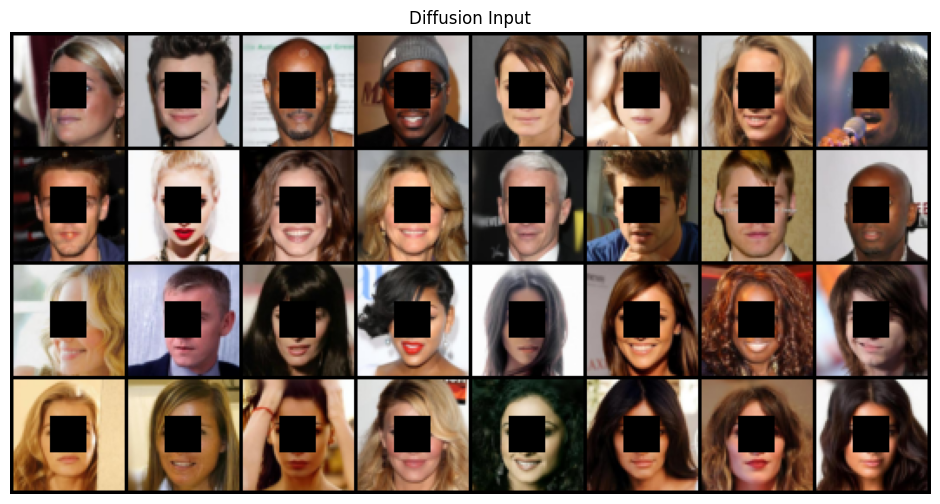

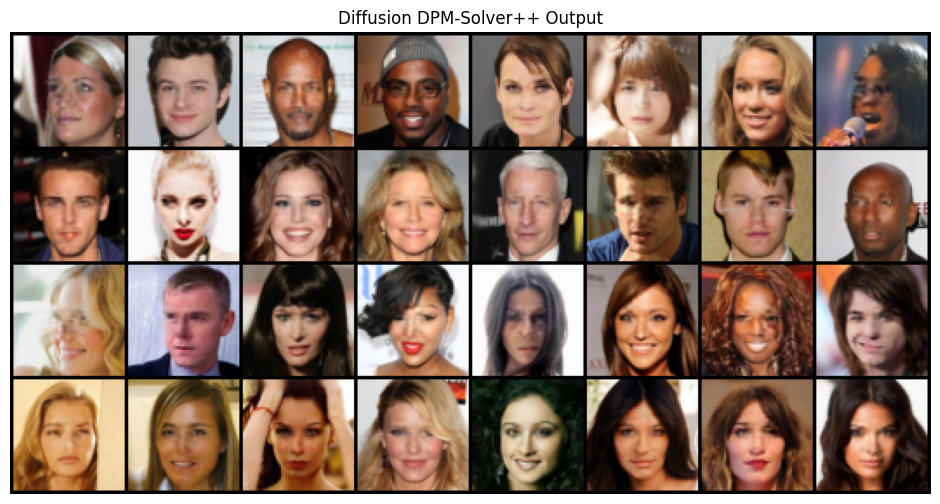

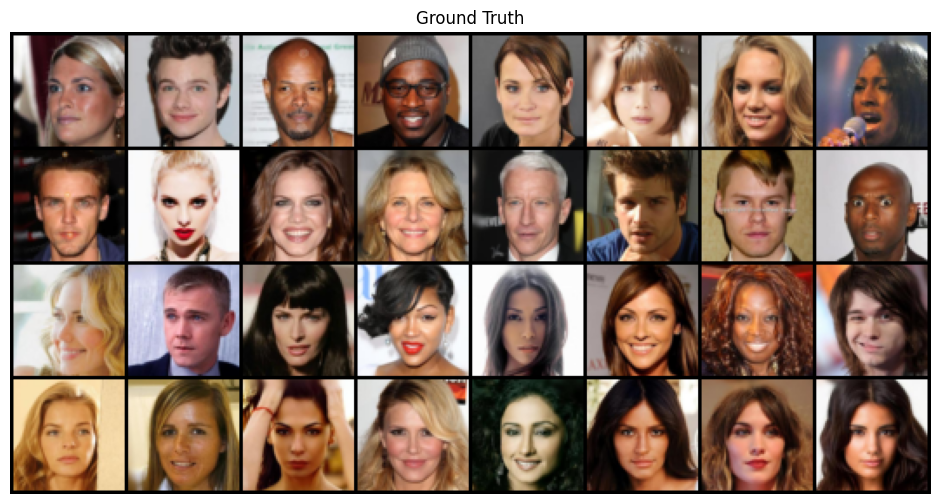

In [34]:
show_batch(all_cond[:32], nrow=8, title="Diffusion Input")
show_batch(all_result[:32], nrow=8, title="Diffusion DPM-Solver++ Output")
show_batch(all_gt[:32], nrow=8, title="Ground Truth")

### UniPC

In [25]:
@torch.no_grad()
def diffusion_inpaint_unipc(
    model,
    cond_image,
    mask,
    num_inference_steps=100,
    device=None,
):
    model.eval()

    if device is None:
        device = cond_image.device

    cond_image = cond_image.to(device)
    mask = mask.to(device).float()

    # cond_image: known region giữ ảnh thật, missing region = -1
    # visible_image: known region giữ ảnh thật, missing region = 0
    visible_image = cond_image * (1 - mask)

    scheduler = UniPCMultistepScheduler(
        num_train_timesteps=1000,
        beta_schedule="squaredcos_cap_v2",
        prediction_type="sample",
    )

    scheduler.set_timesteps(
        num_inference_steps,
        device=device
    )

    # x_T: known region sạch, missing region là Gaussian noise
    x = torch.randn_like(cond_image)
    x = visible_image + x * mask

    for t in tqdm(scheduler.timesteps, desc="UniPC Inpainting Sampling"):
        batch_size = x.size(0)

        t_batch = torch.full(
            (batch_size,),
            int(t.item()) if torch.is_tensor(t) else int(t),
            device=device,
            dtype=torch.long,
        )

        # Ép known region sạch trước prediction
        x = visible_image + x * mask

        model_input = torch.cat(
            [x, cond_image, mask],
            dim=1
        )

        # prediction_type="sample": model output là pred_x0
        pred_x0 = model(
            model_input,
            t_batch
        ).sample

        x = scheduler.step(
            model_output=pred_x0,
            timestep=t,
            sample=x,
        ).prev_sample

        # Ép known region sạch sau update
        x = visible_image + x * mask

    return x.clamp(-1, 1)

In [26]:
with torch.no_grad():
    diffusion_result = diffusion_inpaint_unipc(
        model=diffusion_model,
        cond_image=cond_image,
        mask=mask,
        num_inference_steps=150,
        device=device,
    )

all_gt = gt_image.detach().cpu()
all_cond = cond_image.detach().cpu()
all_result = diffusion_result.detach().cpu()

UniPC Inpainting Sampling: 100%|██████████| 150/150 [00:58<00:00,  2.56it/s]


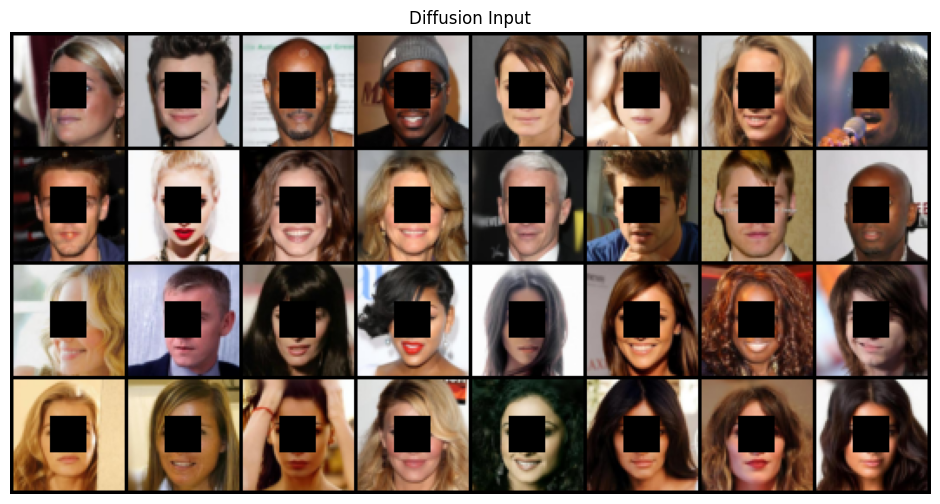

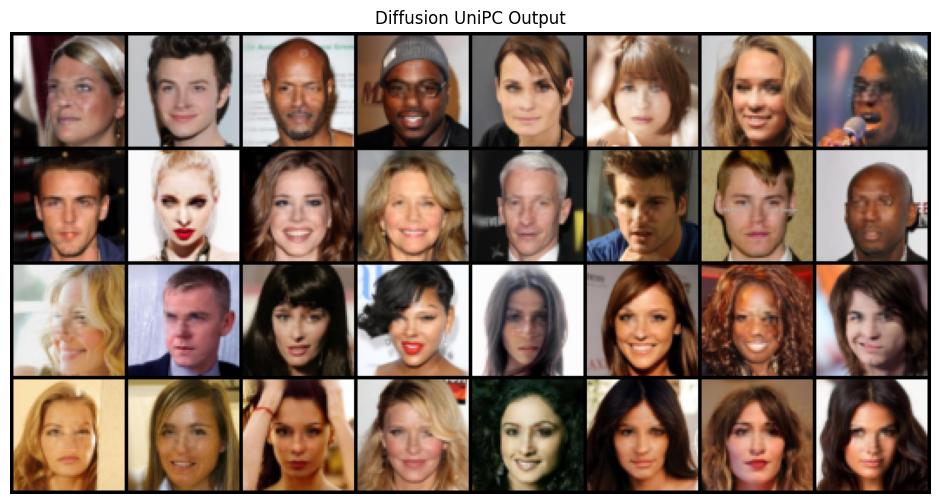

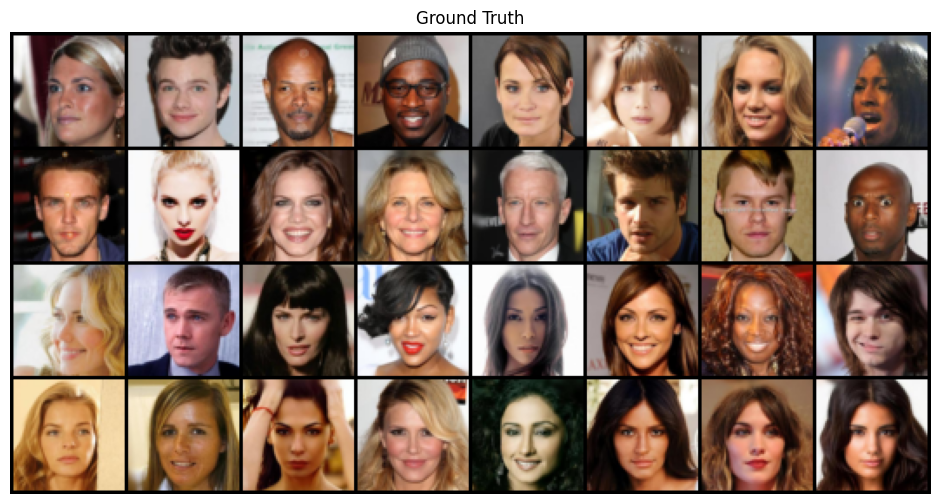

In [28]:
show_batch(all_cond[:32], nrow=8, title="Diffusion Input")
show_batch(all_result[:32], nrow=8, title="Diffusion UniPC Output")
show_batch(all_gt[:32], nrow=8, title="Ground Truth")